# Import

In [435]:
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, Model, Input
import numpy as np
from sklearn.preprocessing import OrdinalEncoder , StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')


## Config

In [436]:
gpus = tf.config.list_physical_devices("GPU")
for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
        print(f"Enabled memory growth for {gpu}")
    except Exception as e:
        print(e)

# Functions

In [437]:
global_split_index_1 = 0
global_split_index_2 = 0

In [438]:
def make_ds(series, seq_length, batch_size, target, shuffle=False):
    x = series.drop(columns=target).to_numpy()
    y = series[target].to_numpy().astype("float32")    # always slice from the numpy array
    y = y.astype("float32")

    return tf.keras.utils.timeseries_dataset_from_array(
        data=x,
        targets=y,
        sequence_length=seq_length,
        batch_size=batch_size,
        shuffle=shuffle,
        seed=42
    )

def train_valid_test_split(df, train_pct=0.90, valid_pct=0.10):

    split_index_1 = int(len(df) * train_pct)
    split_index_2 = int(len(df) * (train_pct+valid_pct))

    global global_split_index_1
    global global_split_index_2

    global_split_index_1 = split_index_1
    global_split_index_2 = split_index_2

    train_df = df.iloc[:split_index_1].copy()
    valid_df = df.iloc[split_index_1:split_index_2].copy()
    # test_df = df.iloc[split_index_2:].copy()


    print(f"""
        split index 1: {split_index_1}
        split index 2: {split_index_2}""")
    return (train_df, valid_df)

def reuse_split(df):

    global global_split_index_1
    global global_split_index_2

    train_df = df.iloc[:global_split_index_1].copy()
    valid_df = df.iloc[global_split_index_1:global_split_index_2].copy()
    # test_df = df.iloc[global_split_index_2:].copy()

    return (train_df, valid_df)

# Load Data

## Tracks

In [439]:
Bahrain_df_fp1_2022 = pd.read_csv("Bahrains/Round_1_Bahrain Grand Prix_2022_FP1.csv")
Bahrain_df_fp1_2022["Session"] = 1
Bahrain_df_fp1_2022["year"] = 2022
Bahrain_df_fp2_2022 = pd.read_csv("Bahrains/Round_1_Bahrain Grand Prix_2022_FP2.csv")
Bahrain_df_fp2_2022["Session"] = 2
Bahrain_df_fp2_2022["year"] = 2022
Bahrain_df_fp3_2022 = pd.read_csv("Bahrains/Round_1_Bahrain Grand Prix_2022_FP3.csv")
Bahrain_df_fp3_2022["Session"] = 3
Bahrain_df_fp3_2022["year"] = 2022
Bahrain_df_race_2022 = pd.read_csv("Bahrains/Round_1_Bahrain Grand Prix_2022_R.csv")
Bahrain_df_race_2022["Session"] = 4
Bahrain_df_race_2022["year"] = 2022

Bahrain_df_fp1_2023 = pd.read_csv("Bahrains/Round_1_Bahrain Grand Prix_2023_FP1.csv")
Bahrain_df_fp1_2023["Session"] = 1
Bahrain_df_fp1_2023["year"] = 2023
Bahrain_df_fp2_2023 = pd.read_csv("Bahrains/Round_1_Bahrain Grand Prix_2023_FP2.csv")
Bahrain_df_fp2_2023["Session"] = 2
Bahrain_df_fp2_2023["year"] = 2023
Bahrain_df_fp3_2023 = pd.read_csv("Bahrains/Round_1_Bahrain Grand Prix_2023_FP3.csv")
Bahrain_df_fp3_2023["Session"] = 3
Bahrain_df_fp3_2023["year"] = 2023
Bahrain_df_race_2023 = pd.read_csv("Bahrains/Round_1_Bahrain Grand Prix_2023_R.csv")
Bahrain_df_race_2023["Session"] = 4
Bahrain_df_race_2023["year"] = 2023

Bahrain_df_fp1_2024 = pd.read_csv("Bahrains/Round_1_Bahrain Grand Prix_2024_FP1.csv")
Bahrain_df_fp1_2024["Session"] = 1
Bahrain_df_fp1_2024["year"] = 2024
Bahrain_df_fp2_2024 = pd.read_csv("Bahrains/Round_1_Bahrain Grand Prix_2024_FP2.csv")
Bahrain_df_fp2_2024["Session"] = 2
Bahrain_df_fp2_2024["year"] = 2024
Bahrain_df_fp3_2024 = pd.read_csv("Bahrains/Round_1_Bahrain Grand Prix_2024_FP3.csv")
Bahrain_df_fp3_2024["Session"] = 3
Bahrain_df_fp3_2024["year"] = 2024
Bahrain_df_race_2024 = pd.read_csv("Bahrains/Round_1_Bahrain Grand Prix_2024_R.csv")
Bahrain_df_race_2024["Session"] = 4
Bahrain_df_race_2024["year"] = 2024

Bahrain_df_fp1_2025 = pd.read_csv("Bahrains/Round_1_Bahrain Grand Prix_2025_FP1.csv")
Bahrain_df_fp1_2025["Session"] = 1
Bahrain_df_fp1_2025["year"] = 2025
Bahrain_df_fp2_2025 = pd.read_csv("Bahrains/Round_1_Bahrain Grand Prix_2025_FP2.csv")
Bahrain_df_fp2_2025["Session"] = 2
Bahrain_df_fp2_2025["year"] = 2025
Bahrain_df_fp3_2025 = pd.read_csv("Bahrains/Round_1_Bahrain Grand Prix_2025_FP3.csv")
Bahrain_df_fp3_2025["Session"] = 3
Bahrain_df_fp3_2025["year"] = 2025
Bahrain_df_race_2025 = pd.read_csv("Bahrains/Round_1_Bahrain Grand Prix_2025_R.csv")
Bahrain_df_race_2025["Session"] = 4
Bahrain_df_race_2025["year"] = 2025

Bahrain_df = pd.concat([Bahrain_df_fp1_2022,
                        Bahrain_df_fp2_2022,
                        Bahrain_df_fp3_2022,
                        Bahrain_df_race_2022,
                        Bahrain_df_fp1_2023,
                        Bahrain_df_fp2_2023,
                        Bahrain_df_fp3_2023,
                        Bahrain_df_race_2023,
                        Bahrain_df_fp1_2024,
                        Bahrain_df_fp2_2024,
                        Bahrain_df_fp3_2024,
                        Bahrain_df_race_2024,
                        Bahrain_df_fp1_2025,
                        Bahrain_df_fp2_2025,
                        Bahrain_df_fp3_2025,
                        Bahrain_df_race_2025,
                        ])


## concat all

In [440]:
# total_df = pd.concat([Bahrain_df,Bahrainn_df])

# total_df = pd.concat([Bahrain_df,Bahrainn_df,Australian_df,Emilia_Romagna_df,Spanish_df,Azerbaijan_df,Canadian_df,British_df,Austrian_df,French_df,Hungarian_df,Belgian_df,Dutch_df,Italian_df,Singapore_df,Japanese_df,United_States_df,Mexico_City_df,Sao_Paulo_df,Abu_Dhabi_df])

# Filters

In [441]:
Bahrain_df.columns

Index(['Unnamed: 0', 'Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber',
       'Stint', 'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time',
       'Sector3Time', 'Sector1SessionTime', 'Sector2SessionTime',
       'Sector3SessionTime', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST',
       'IsPersonalBest', 'Compound', 'TyreLife', 'FreshTyre', 'Team',
       'LapStartTime', 'LapStartDate', 'TrackStatus', 'Position', 'Deleted',
       'DeletedReason', 'FastF1Generated', 'IsAccurate', 'AirTemp', 'Humidity',
       'Pressure', 'Rainfall', 'TrackTemp', 'WindDirection', 'WindSpeed',
       'Circuit', 'Track_length', 'Number_of_corners', 'Session', 'year'],
      dtype='object')

In [442]:
# Bahrainn_df = Bahrainn_df[Bahrainn_df["TrackStatus"] == 1]       ## focusing purely on green flag laps causes continuity issues

In [443]:
Bahrain_df.to_csv("bahrains.csv")

Bahrain_df = Bahrain_df.dropna(subset=["Sector1Time", "Sector2Time","Sector3Time"])

# column management

In [444]:
Bahrain_Ver_df = Bahrain_df.copy()

In [445]:
Bahrain_Ver_df["SC_active"] = (
    Bahrain_Ver_df["TrackStatus"]
    .astype("string")                      # robust to mixed types/NaN
    .str.contains("4")
    .astype("int32")
)


In [446]:
Bahrain_Ver_df = Bahrain_Ver_df[Bahrain_Ver_df["Driver"] == "VER"]
Bahrain_Ver_df = Bahrain_Ver_df.drop(columns=["Unnamed: 0","DriverNumber","Driver","Time","IsPersonalBest","LapStartTime","Position","Deleted","DeletedReason", "FastF1Generated", "IsAccurate",'Sector1SessionTime',
       'Sector2SessionTime', 'Sector3SessionTime','FreshTyre',"SpeedI1","SpeedI2","SpeedFL","SpeedST","Team","LapTime","PitOutTime","PitInTime","Rainfall","Pressure","Humidity","TrackStatus",])

no more sector time melt, keep them as columns and now they are 3 targets for 3 models. or maybe 3 targets for one?

In [447]:
Bahrain_Ver_df = Bahrain_Ver_df.sort_values(            # sorting by lap start date/time
    by=["LapStartDate"],
    ascending=True
)

Bahrain_Ver_df = Bahrain_Ver_df.drop(columns="LapStartDate")

In [448]:

rad = np.deg2rad(Bahrain_Ver_df["WindDirection"])
Bahrain_Ver_df["WindDir_sin"] = np.sin(rad)
Bahrain_Ver_df["WindDir_cos"] = np.cos(rad)
Bahrain_Ver_df.drop(columns=["WindDirection"], inplace=True)


In [449]:
Bahrain_Ver_df = Bahrain_Ver_df.reset_index(drop=True)

window_size = 10


for i in range (1,4):
    Bahrain_Ver_df[f"Sector{i}Time"] = pd.to_timedelta(Bahrain_Ver_df[f"Sector{i}Time"])
    Bahrain_Ver_df[f"Sector{i}Time"] = Bahrain_Ver_df[f"Sector{i}Time"].dt.total_seconds()

    # Bahrain_Ver_df = Bahrain_Ver_df.dropna(subset=[f"Sector{i}Time"])                                                 #lazy destructive method
    roll_medians = Bahrain_Ver_df[f"Sector{i}Time"].rolling(window=window_size, min_periods=1).median()
    Bahrain_Ver_df[f"Sector{i}Time"] = Bahrain_Ver_df[f"Sector{i}Time"].fillna(roll_medians)


implementing 107% rule in the form of clipping to deal with extreme times in training data (safety cars for example) again not the best solution but simple enough for testing

In [450]:
# for col in ["Sector1Time", "Sector2Time", "Sector3Time"]:

#     baseline = Bahrain_Ver_df[col].rolling(window=window_size, min_periods=1).mean()
#     clip_level = 1.07 * baseline
#     Bahrain_Ver_df[col] = Bahrain_Ver_df[col].clip(upper=clip_level)


Bahrain_Ver_df["TyreLife"] = Bahrain_Ver_df["TyreLife"].ffill()

# Splitting

In [451]:
Train_test_valid_sector1_df = Bahrain_Ver_df.copy()
Train_test_valid_sector2_df = Bahrain_Ver_df.copy()
Train_test_valid_sector3_df = Bahrain_Ver_df.copy()

Train_test_valid_sector1_df = Train_test_valid_sector1_df.drop(columns=["Sector2Time","Sector3Time"])
Train_test_valid_sector2_df = Train_test_valid_sector2_df.drop(columns=["Sector1Time","Sector3Time"])
Train_test_valid_sector3_df = Train_test_valid_sector3_df.drop(columns=["Sector1Time","Sector2Time"])

Train_valid_sector1_df = Train_test_valid_sector1_df[~((Train_test_valid_sector1_df["Session"] == 4) & (Train_test_valid_sector1_df["year"] == 2025))]
Train_valid_sector2_df = Train_test_valid_sector2_df[~((Train_test_valid_sector2_df["Session"] == 4) & (Train_test_valid_sector2_df["year"] == 2025))]
Train_valid_sector3_df = Train_test_valid_sector3_df[~((Train_test_valid_sector3_df["Session"] == 4) & (Train_test_valid_sector3_df["year"] == 2025))]

old version of sliptting below now we are using one race session as test  and all previous sessions including previous races as train

In [452]:
Ver_train_sector1, Ver_valid_sector1 = train_valid_test_split(Train_valid_sector1_df)
Ver_train_sector2, Ver_valid_sector2 = reuse_split(Train_valid_sector2_df,)
Ver_train_sector3, Ver_valid_sector3 = reuse_split(Train_valid_sector3_df)

Ver_test_sector1 = Train_test_valid_sector1_df[(Train_test_valid_sector1_df["Session"] == 4) & (Train_test_valid_sector1_df["year"] == 2025)]
Ver_test_sector2 = Train_test_valid_sector2_df[(Train_test_valid_sector2_df["Session"] == 4) & (Train_test_valid_sector2_df["year"] == 2025)]
Ver_test_sector3 = Train_test_valid_sector3_df[(Train_test_valid_sector3_df["Session"] == 4) & (Train_test_valid_sector3_df["year"] == 2025)]


        split index 1: 270
        split index 2: 300


# Encoding and numerical formatting

In [453]:
ints_that_should_not_be_floats = ['LapNumber','Stint','TyreLife',"Number_of_corners"]
categorical_cols = ["Compound","Circuit"]

ordinal_encoder_1 = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1,            # all unseen categories map to -1
    encoded_missing_value=-2     # missing values map to -2
)
ordinal_encoder_2 = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1,            
    encoded_missing_value=-2     
)
ordinal_encoder_3 = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1,            
    encoded_missing_value=-2    
)

## S1

ordinal_encoder_1.fit(Ver_train_sector1[categorical_cols])

Ver_train_sector1[categorical_cols] = ordinal_encoder_1.transform(Ver_train_sector1[categorical_cols]).astype("int32")
Ver_train_sector1[ints_that_should_not_be_floats] = Ver_train_sector1[ints_that_should_not_be_floats].astype("int32")

Ver_valid_sector1[categorical_cols] = ordinal_encoder_1.transform(Ver_valid_sector1[categorical_cols]).astype("int32")
Ver_valid_sector1[ints_that_should_not_be_floats] = Ver_valid_sector1[ints_that_should_not_be_floats].astype("int32")

Ver_test_sector1[categorical_cols] = ordinal_encoder_1.transform(Ver_test_sector1[categorical_cols]).astype("int32")
Ver_test_sector1[ints_that_should_not_be_floats] = Ver_test_sector1[ints_that_should_not_be_floats].astype("int32")

## S2

ordinal_encoder_2.fit(Ver_train_sector2[categorical_cols])

Ver_train_sector2[categorical_cols] = ordinal_encoder_2.transform(Ver_train_sector2[categorical_cols]).astype("int32")
Ver_train_sector2[ints_that_should_not_be_floats] = Ver_train_sector2[ints_that_should_not_be_floats].astype("int32")

Ver_valid_sector2[categorical_cols] = ordinal_encoder_2.transform(Ver_valid_sector2[categorical_cols]).astype("int32")
Ver_valid_sector2[ints_that_should_not_be_floats] = Ver_valid_sector2[ints_that_should_not_be_floats].astype("int32")

Ver_test_sector2[categorical_cols] = ordinal_encoder_2.transform(Ver_test_sector2[categorical_cols]).astype("int32")
Ver_test_sector2[ints_that_should_not_be_floats] = Ver_test_sector2[ints_that_should_not_be_floats].astype("int32")

## S3

ordinal_encoder_3.fit(Ver_train_sector3[categorical_cols])

Ver_train_sector3[categorical_cols] = ordinal_encoder_3.transform(Ver_train_sector3[categorical_cols]).astype("int32")
Ver_train_sector3[ints_that_should_not_be_floats] = Ver_train_sector3[ints_that_should_not_be_floats].astype("int32")

Ver_valid_sector3[categorical_cols] = ordinal_encoder_3.transform(Ver_valid_sector3[categorical_cols]).astype("int32")
Ver_valid_sector3[ints_that_should_not_be_floats] = Ver_valid_sector3[ints_that_should_not_be_floats].astype("int32")

Ver_test_sector3[categorical_cols] = ordinal_encoder_3.transform(Ver_test_sector3[categorical_cols]).astype("int32")
Ver_test_sector3[ints_that_should_not_be_floats] = Ver_test_sector3[ints_that_should_not_be_floats].astype("int32")


/tmp/ipykernel_821784/1776632001.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Ver_test_sector1[categorical_cols] = ordinal_encoder_1.transform(Ver_test_sector1[categorical_cols]).astype("int32")
/tmp/ipykernel_821784/1776632001.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Ver_test_sector1[ints_that_should_not_be_floats] = Ver_test_sector1[ints_that_should_not_be_floats].astype("int32")
/tmp/ipykernel_821784/1776632001.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a

In [454]:
sect_1_corr_matrix = Ver_train_sector1.corr()
sect_2_corr_matrix = Ver_train_sector2.corr()
sect_3_corr_matrix = Ver_train_sector3.corr()



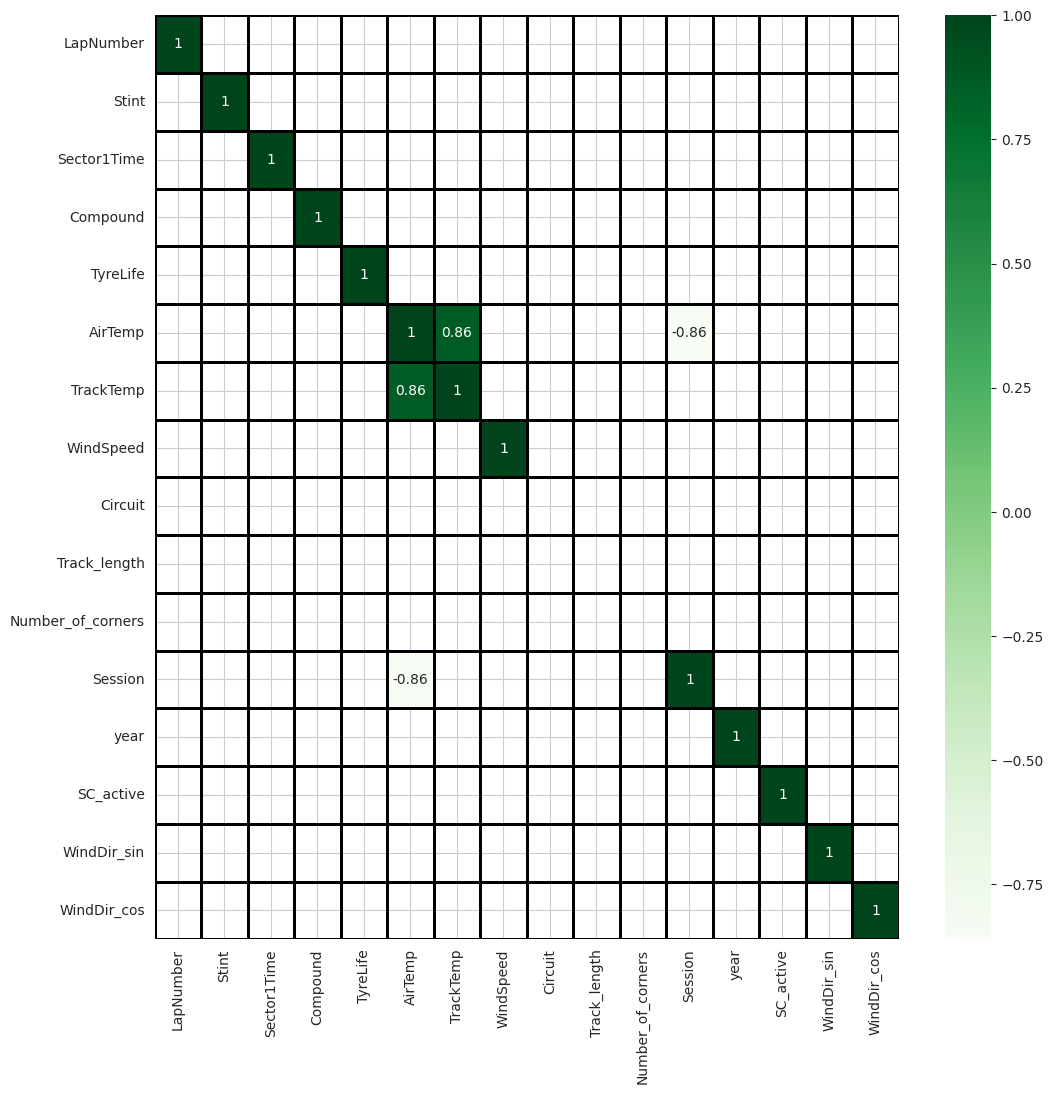

In [455]:
plt.figure(figsize=(12,12))
sns.heatmap(
    sect_1_corr_matrix,
    mask = sect_1_corr_matrix.abs() < 0.8,     ## our threshold for colienarity suspicion is 80% correlation between features
    annot=True,
    cmap="Greens",
    linewidths=0.75,
    linecolor="black"
    )
plt.show()

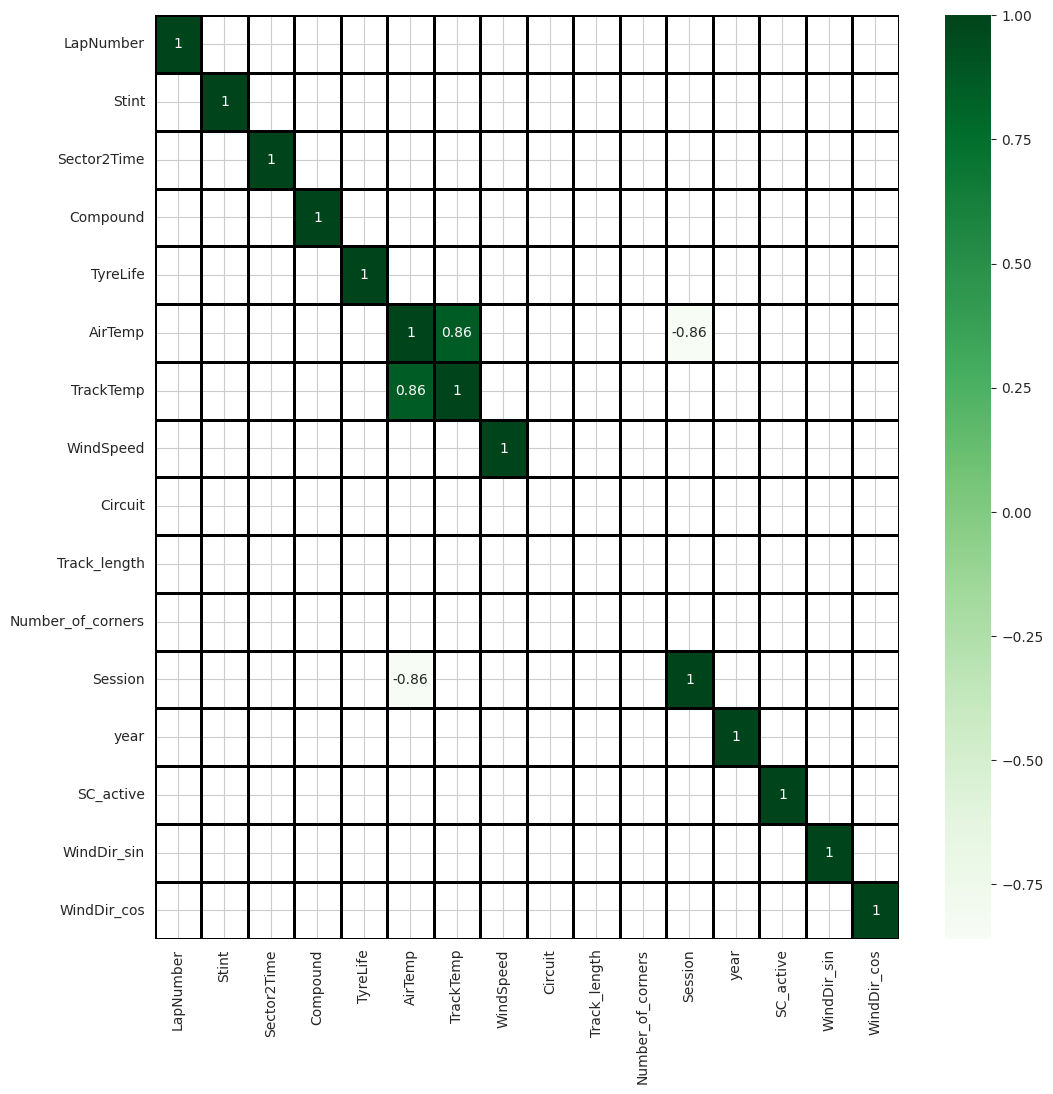

In [456]:
plt.figure(figsize=(12,12))
sns.heatmap(
    sect_2_corr_matrix,
    mask = sect_2_corr_matrix.abs() < 0.8,     ## our threshold for colienarity suspicion is 80% correlation between features
    annot=True,
    cmap="Greens",
    linewidths=0.75,
    linecolor="black"
    )
plt.show()

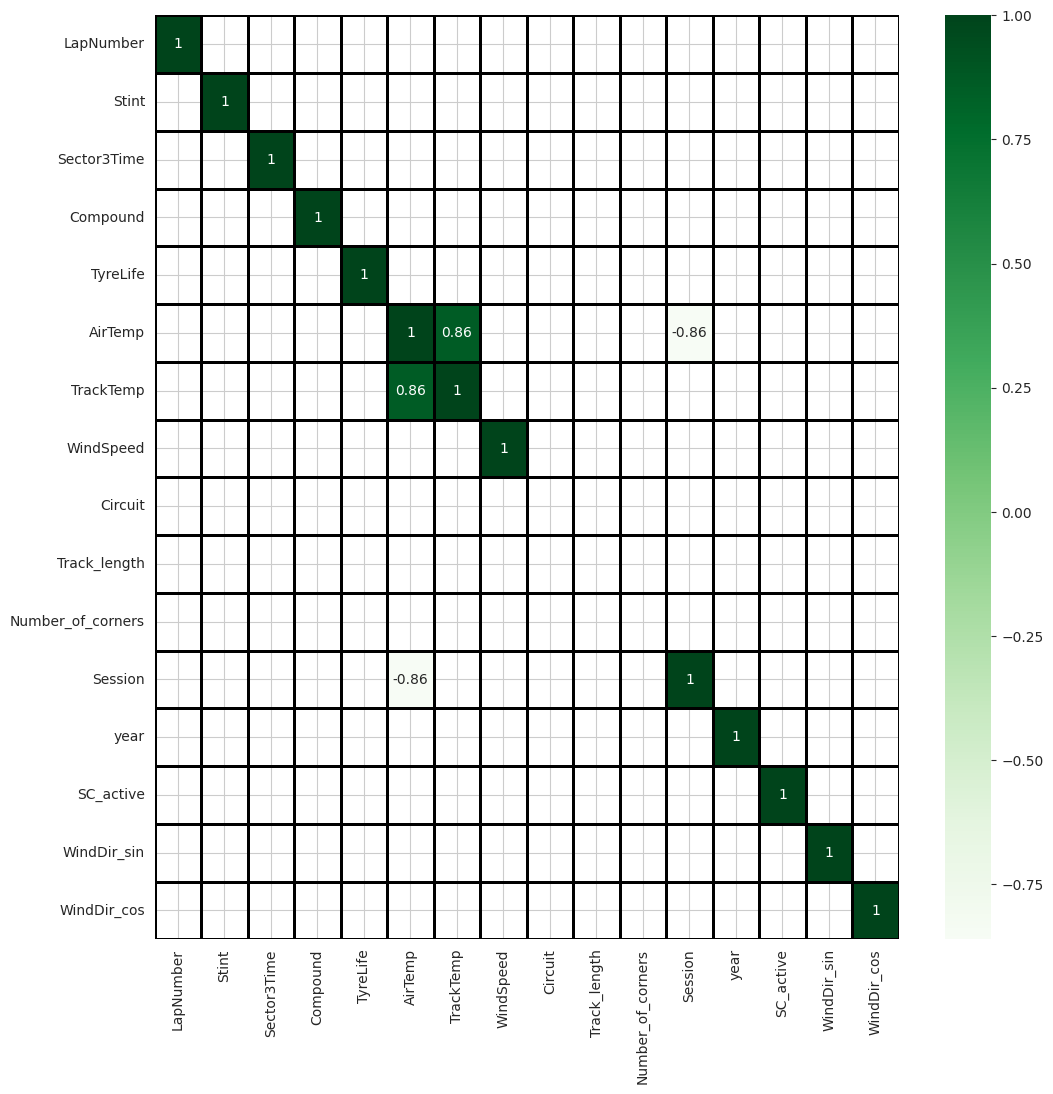

In [457]:
plt.figure(figsize=(12,12))
sns.heatmap(
    sect_3_corr_matrix,
    mask = sect_3_corr_matrix.abs() < 0.8,     ## our threshold for colienarity suspicion is 80% correlation between features
    annot=True,
    cmap="Greens",
    linewidths=0.75,
    linecolor="black"
    )
plt.show()

‘1’: Track clear (beginning of session or to indicate the end
    of another status)

‘2’: Yellow flag (sectors are unknown)

‘3’: ??? Never seen so far, does not exist?

‘4’: Safety Car

‘5’: Red Flag

‘6’: Virtual Safety Car deployed

‘7’: Virtual Safety Car ending (As indicated on the drivers steering wheel, on tv and so on; status ‘1’ will mark the actual end)

# Scaling

In [458]:
to_be_standardised = ['LapNumber','Stint','TyreLife','Session',"AirTemp","TrackTemp","WindSpeed","Track_length","Number_of_corners","year","WindDir_cos","WindDir_sin"]

standard_scaler_1 = StandardScaler()
standard_scaler_2 = StandardScaler()        # not necessary but makes it more diffiult to perform transformations with incorectly fit scalars later 
standard_scaler_3 = StandardScaler()

y_standard_scaler_1 = StandardScaler()
y_standard_scaler_2 = StandardScaler()
y_standard_scaler_3 = StandardScaler()


## S1

standard_scaler_1.fit(Ver_train_sector1[to_be_standardised])
y_standard_scaler_1.fit(Ver_train_sector1[["Sector1Time"]])


Ver_train_sector1[to_be_standardised] = standard_scaler_1.transform(Ver_train_sector1[to_be_standardised]) 
Ver_valid_sector1[to_be_standardised] = standard_scaler_1.transform(Ver_valid_sector1[to_be_standardised])
Ver_test_sector1[to_be_standardised] = standard_scaler_1.transform(Ver_test_sector1[to_be_standardised]) 

Ver_train_sector1["Sector1Time"] = y_standard_scaler_1.transform(Ver_train_sector1[["Sector1Time"]]) 
Ver_valid_sector1["Sector1Time"] = y_standard_scaler_1.transform(Ver_valid_sector1[["Sector1Time"]])
Ver_test_sector1["Sector1Time"] = y_standard_scaler_1.transform(Ver_test_sector1[["Sector1Time"]]) 

## S2

standard_scaler_2.fit(Ver_train_sector2[to_be_standardised])
y_standard_scaler_2.fit(Ver_train_sector2[["Sector2Time"]])

Ver_train_sector2[to_be_standardised] = standard_scaler_2.transform(Ver_train_sector2[to_be_standardised]) 
Ver_valid_sector2[to_be_standardised] = standard_scaler_2.transform(Ver_valid_sector2[to_be_standardised])
Ver_test_sector2[to_be_standardised] = standard_scaler_2.transform(Ver_test_sector2[to_be_standardised]) 

Ver_train_sector2["Sector2Time"] = y_standard_scaler_2.transform(Ver_train_sector2[["Sector2Time"]]) 
Ver_valid_sector2["Sector2Time"] = y_standard_scaler_2.transform(Ver_valid_sector2[["Sector2Time"]])
Ver_test_sector2["Sector2Time"] = y_standard_scaler_2.transform(Ver_test_sector2[["Sector2Time"]]) 


## S3

standard_scaler_3.fit(Ver_train_sector3[to_be_standardised])
y_standard_scaler_3.fit(Ver_train_sector3[["Sector3Time"]])

Ver_train_sector3[to_be_standardised] = standard_scaler_3.transform(Ver_train_sector3[to_be_standardised]) 
Ver_valid_sector3[to_be_standardised] = standard_scaler_3.transform(Ver_valid_sector3[to_be_standardised])
Ver_test_sector3[to_be_standardised] = standard_scaler_3.transform(Ver_test_sector3[to_be_standardised]) 

Ver_train_sector3["Sector3Time"] = y_standard_scaler_3.transform(Ver_train_sector3[["Sector3Time"]]) 
Ver_valid_sector3["Sector3Time"] = y_standard_scaler_3.transform(Ver_valid_sector3[["Sector3Time"]])
Ver_test_sector3["Sector3Time"] = y_standard_scaler_3.transform(Ver_test_sector3[["Sector3Time"]]) 

/tmp/ipykernel_821784/3478808900.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Ver_test_sector1[to_be_standardised] = standard_scaler_1.transform(Ver_test_sector1[to_be_standardised])
/tmp/ipykernel_821784/3478808900.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Ver_test_sector1["Sector1Time"] = y_standard_scaler_1.transform(Ver_test_sector1[["Sector1Time"]])
/tmp/ipykernel_821784/3478808900.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try 

# datasets

In [459]:
seq_length = 6
batchsize = 128

Ver_train_sector1_ds = make_ds(Ver_train_sector1, seq_length, batchsize, "Sector1Time", shuffle=True)               # data, seq length, batchsize,shuffle # needs to be numpy format
Ver_valid_sector1_ds = make_ds(Ver_valid_sector1, seq_length, batchsize, "Sector1Time", shuffle=False)
Ver_test_sector1_ds = make_ds(Ver_test_sector1, seq_length, batchsize, "Sector1Time", shuffle=False)

Ver_train_sector2_ds = make_ds(Ver_train_sector2, seq_length, batchsize, "Sector2Time", shuffle=True)               # data, seq length, batchsize,shuffle # needs to be numpy format
Ver_valid_sector2_ds = make_ds(Ver_valid_sector2, seq_length, batchsize, "Sector2Time", shuffle=False)
Ver_test_sector2_ds = make_ds(Ver_test_sector2, seq_length, batchsize, "Sector2Time", shuffle=False)

Ver_train_sector3_ds = make_ds(Ver_train_sector3, seq_length, batchsize, "Sector3Time", shuffle=True)               # data, seq length, batchsize,shuffle # needs to be numpy format
Ver_valid_sector3_ds = make_ds(Ver_valid_sector3, seq_length, batchsize, "Sector3Time", shuffle=False)
Ver_test_sector3_ds = make_ds(Ver_test_sector3, seq_length, batchsize, "Sector3Time", shuffle=False)


# Sanity Checks

In [460]:
for batch_x, batch_y in Ver_train_sector1_ds.take(1):          # takes firs t batch of datset
    print("X shape S1:", batch_x.shape)                        # (viable windows, seq_length, features)
    print("y shape S1:", batch_y.shape)                        # (viable windows) for single target

for batch_x, batch_y in Ver_valid_sector1_ds.take(1):
    print("X shape S2:", batch_x.shape)                        # (viable windows, seq_length, features)
    print("y shape S2:", batch_y.shape)                        # (viable windows,) for single target

for batch_x, batch_y in Ver_test_sector1_ds.take(1):
    print("X shape S3:", batch_x.shape)                        # (viable windows, seq_length, features)
    print("y shape S3:", batch_y.shape)                        # (viable windows,) for single target

X shape S1: (128, 6, 15)
y shape S1: (128,)
X shape S2: (25, 6, 15)
y shape S2: (25,)
X shape S3: (51, 6, 15)
y shape S3: (51,)


In [461]:
# Get the first window and its target

for batch_x, batch_y in Ver_train_sector1_ds.take(1):
    first_window = batch_x[0].numpy()
    first_target = batch_y[0].numpy()
    print("First window last row (features):", first_window[-1])
    print("First target (Sector1Time):", first_target)


First window last row (features): [-6.44062739e-01  1.88205064e+00  2.00000000e+00 -7.64179129e-01
  1.02377084e+00  1.82219608e+00  1.39029252e+00  0.00000000e+00
 -8.88178420e-16  0.00000000e+00 -1.69476125e-01 -2.42712680e-01
  0.00000000e+00  2.13963567e-01  2.38058004e-01]
First target (Sector1Time): 1.3505806


In [462]:
print("train windows:", tf.data.experimental.cardinality(Ver_train_sector1_ds))
print("valid windows:", tf.data.experimental.cardinality(Ver_valid_sector1_ds))
print("test  windows:", tf.data.experimental.cardinality(Ver_test_sector1_ds))   


train windows: tf.Tensor(3, shape=(), dtype=int64)
valid windows: tf.Tensor(1, shape=(), dtype=int64)
test  windows: tf.Tensor(1, shape=(), dtype=int64)


# Modelling

## Architecture

## defining the transformer

In [463]:
import tensorflow as tf
from tensorflow.keras import layers, Model, Input

class PositionEmbedding(layers.Layer):
    """
    Learnable positional embedding for fixed-length windows.
    Adds a position vector of shape (seq_len, embed_dim) to the inputs.
    """
    def __init__(self, seq_len: int, embed_dim: int, **kwargs):
        super().__init__(**kwargs)
        self.seq_len = seq_len
        self.embed_dim = embed_dim
        self.pos_emb = layers.Embedding(input_dim=seq_len, output_dim=embed_dim)

    def call(self, x):
        # x: (batch, seq_len, embed_dim)
        seq_len = tf.shape(x)[1]
        positions = tf.range(start=0, limit=seq_len, delta=1)
        pos_encoding = self.pos_emb(positions)  # (seq_len, embed_dim)
        return x + pos_encoding

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"seq_len": self.seq_len, "embed_dim": self.embed_dim})
        return cfg


class TransformerBlock(layers.Layer):
    """
    Pre-norm Transformer encoder block (LayerNorm -> MHA -> Dropout -> Residual -> FFN -> Residual).
    """
    def __init__(self, embed_dim: int, num_heads: int, ff_dim: int, rate: float = 0.1, **kwargs):
        super().__init__(**kwargs)
        # Per-head dimension; embed_dim should be divisible by num_heads
        key_dim = max(1, embed_dim // num_heads)

        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.attn = layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=key_dim,            # dimension per head
            output_shape=embed_dim      # project output back to embed_dim for residual add
        )
        self.drop1 = layers.Dropout(rate)

        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.ffn = tf.keras.Sequential([
            layers.Dense(ff_dim, activation="relu"),
            layers.Dense(embed_dim)
        ])
        self.drop2 = layers.Dropout(rate)

    def call(self, inputs, training=None):
        # Pre-norm
        x = self.norm1(inputs)
        attn_output = self.attn(x, x, training=training)
        attn_output = self.drop1(attn_output, training=training)
        x = inputs + attn_output                      # residual 1

        y = self.norm2(x)
        y = self.ffn(y, training=training)
        y = self.drop2(y, training=training)
        return x + y                                  # residual 2

In [464]:
def build_transformer_regressor(seq_len: int,
                                n_features: int,
                                embed_dim: int = 64,
                                num_heads: int = 4,
                                ff_dim: int = 128,
                                num_blocks: int = 2,
                                dropout: float = 0.1):
    """
    Returns a Keras model that takes (seq_len, n_features) and outputs a single scalar.
    """
    inputs = Input(shape=(seq_len, n_features))               # (B, T, F)

    # Project raw features to model dimension first so residuals are well-formed
    x = layers.Dense(embed_dim, name="feature_projection")(inputs)  # (B, T, E)

    # Add positional information
    x = PositionEmbedding(seq_len, embed_dim, name="positional_embedding")(x)

    # Stack N Transformer encoder blocks
    for i in range(num_blocks):
        x = TransformerBlock(embed_dim, num_heads, ff_dim, rate=dropout, name=f"encoder_block_{i+1}")(x)

    # Normalise once at the end
    x = layers.LayerNormalization(epsilon=1e-6, name="final_norm")(x)

    # Option 1: use the last token (matches RNN patterns)
    x = layers.Lambda(lambda t: t[:, -1, :], name="last_token")(x)

    # Option 2 (alternative): GlobalAveragePooling1D to aggregate all timesteps
    # x = layers.GlobalAveragePooling1D(name="gap")(x)

    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(1, name="regression_head")(x)

    model = Model(inputs, outputs, name="transformer_time_series_regressor")
    return model

## build transformers

In [465]:
Ver_sector_1_model = build_transformer_regressor(seq_length,len(Ver_train_sector1.columns)-1)
Ver_sector_2_model = build_transformer_regressor(seq_length,len(Ver_train_sector1.columns)-1)
Ver_sector_3_model = build_transformer_regressor(seq_length,len(Ver_train_sector1.columns)-1)

## defining our tsmixer

In [466]:
import tensorflow as tf
from tensorflow.keras import layers, Model, Input

class TSMixerBlock(layers.Layer):
    """
    TSMixer block that preserves (B, T, F) across residuals.
    - Temporal mix: MLP over time axis (after transpose to make T the last dim), returns to T.
    - Feature mix:  MLP over feature axis, returns to F.
    """
    def __init__(self,
                 time_mlp_units: int = 64,
                 feature_mlp_units: int = 64,
                 dropout: float = 0.1,
                 **kwargs):
        super().__init__(**kwargs)
        self.time_mlp_units = time_mlp_units
        self.feature_mlp_units = feature_mlp_units
        self.dropout = layers.Dropout(dropout)

        # Pre-norms
        self.norm_time = layers.LayerNormalization(epsilon=1e-6)
        self.norm_feat = layers.LayerNormalization(epsilon=1e-6)

        # Temporal mixer (applied on (B,F,T))
        self.time_dense_1 = layers.Dense(time_mlp_units, activation="gelu")
        self.time_dense_2 = None   # will be Dense(T) in build()

        # Feature mixer (applied on (B,T,F))
        self.feature_dense_1 = layers.Dense(feature_mlp_units, activation="gelu")
        self.feature_dense_2 = None  # will be Dense(F) in build()

    def build(self, input_shape):
        # input_shape = (B, T, F)
        _, T, F = input_shape

        # Return to original sizes for residual adds
        self.time_dense_2 = layers.Dense(T)   # back to time length T
        self.feature_dense_2 = layers.Dense(F)  # back to feature size F

        super().build(input_shape)

    def call(self, x, training=None):
        # ----- Temporal mixing: mix over time axis -----
        t = self.norm_time(x)                         # (B, T, F)
        t = tf.transpose(t, perm=[0, 2, 1])          # (B, F, T)  → Dense acts on last axis (T)
        t = self.time_dense_1(t)                     # (B, F, Ht)
        t = self.time_dense_2(t)                     # (B, F, T)
        t = tf.transpose(t, perm=[0, 2, 1])          # (B, T, F)
        t = self.dropout(t, training=training)
        x = x + t                                     # residual, shapes now match

        # ----- Feature mixing: mix over feature axis -----
        f = self.norm_feat(x)                        # (B, T, F)
        f = self.feature_dense_1(f)                  # (B, T, Hf)
        f = self.feature_dense_2(f)                  # (B, T, F)
        f = self.dropout(f, training=training)
        x = x + f                                     # residual

        return x


def build_tsmixer_regressor(seq_len: int,
                            n_features: int,
                            depth: int = 3,
                            time_mlp_units: int = 64,
                            feature_mlp_units: int = 64,
                            dropout: float = 0.1):
    """
    (seq_len, n_features) → scalar. Uses last timestep representation for regression head.
    """
    inputs = Input(shape=(seq_len, n_features))  # (B, T, F)
    x = inputs

    for i in range(depth):
        x = TSMixerBlock(
            time_mlp_units=time_mlp_units,
            feature_mlp_units=feature_mlp_units,
            dropout=dropout,
            name=f"tsmixer_block_{i+1}",
        )(x)

    x = layers.LayerNormalization(epsilon=1e-6, name="final_norm")(x)
    x = layers.Lambda(lambda t: t[:, -1, :], name="last_token")(x)  # (B, F)

    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(1, name="regression_head")(x)

    return Model(inputs, outputs, name="tsmixer_time_series_regressor")

## Build TSMixers

In [467]:

# Ver_sector_1_model = build_tsmixer_regressor(
#     seq_len=seq_length,
#     n_features=len(Ver_train_sector1.columns) - 1,   # drop the single target
#     depth=3,
#     time_mlp_units=64,
#     feature_mlp_units=64,
#     dropout=0.1
# )

# Ver_sector_2_model = build_tsmixer_regressor(
#     seq_len=seq_length,
#     n_features=len(Ver_train_sector2.columns) - 1,   # <-- was sector1 by mistake
#     depth=3,
#     time_mlp_units=64,
#     feature_mlp_units=64,
#     dropout=0.1
# )

# Ver_sector_3_model = build_tsmixer_regressor(
#     seq_len=seq_length,
#     n_features=len(Ver_train_sector3.columns) - 1,   # <-- was sector1 by mistake
#     depth=3,
#     time_mlp_units=64,
#     feature_mlp_units=64,
#     dropout=0.1
# )

### Sector 1 model

In [468]:
# Ver_sector_1_model = tf.keras.Sequential([
#     tf.keras.layers.InputLayer(shape=(seq_length, len(Ver_train_sector1.columns)-1)),
#     tf.keras.layers.Conv1D(
#         filters=32,
#         kernel_size=7,
#         padding="causal",                       ### looks back not forward, no leakage
#         use_bias=False,
#     ),
#     tf.keras.layers.Conv1D(
#         filters=32,
#         kernel_size=7,
#         padding="causal",
#         use_bias=False,
#         activation="relu",
#     ),
#     tf.keras.layers.SpatialDropout1D(0.05),                     ##only after first batch on cnns as every layer would lead to more lag
#     tf.keras.layers.LayerNormalization(),
#     tf.keras.layers.Conv1D(
#         filters=64,
#         kernel_size=5,
#         padding="causal",                       ### looks back not forward, no leakage
#         use_bias=False,
#     ),
#     tf.keras.layers.Conv1D(
#         filters=64,
#         kernel_size=5,
#         padding="causal",
#         use_bias=False,
#         activation="relu",
#     ),
#     tf.keras.layers.LayerNormalization(),
#         tf.keras.layers.Conv1D(
#         filters=128,
#         kernel_size=3,
#         padding="causal",                       ### looks back not forward, no leakage
#         use_bias=False,
#     ),
#     tf.keras.layers.Conv1D(
#         filters=128,
#         kernel_size=3,
#         padding="causal",
#         use_bias=False,
#         activation="relu",
#     ),
#     tf.keras.layers.LayerNormalization(),

#     tf.keras.layers.GRU(128, return_sequences=True),                                      ## return sequences is needed otherwise only last hidden state is returned                           
#     tf.keras.layers.LayerNormalization(),    
#     tf.keras.layers.GRU(64),
#     tf.keras.layers.LayerNormalization(),

#     tf.keras.layers.Dense(128, activation="relu"),
#     tf.keras.layers.Dropout(0.1),
#     tf.keras.layers.Dense(64, activation="relu"),
#     tf.keras.layers.LayerNormalization(),
    
#     tf.keras.layers.Dense(1)

# ])   

### Sector 2 model

In [469]:
# Ver_sector_2_model = tf.keras.Sequential([
#     tf.keras.layers.InputLayer(shape=(seq_length, len(Ver_train_sector1.columns)-1)),
#     tf.keras.layers.Conv1D(
#         filters=32,
#         kernel_size=7,
#         padding="causal",                       ### looks back not forward, no leakage
#         use_bias=False,
#     ),
#     tf.keras.layers.Conv1D(
#         filters=32,
#         kernel_size=7,
#         padding="causal",
#         use_bias=False,
#         activation="relu",
#     ),
#     tf.keras.layers.SpatialDropout1D(0.05),                     ##only after first batch on cnns as every layer would lead to more lag
#     tf.keras.layers.LayerNormalization(),
#     tf.keras.layers.Conv1D(
#         filters=64,
#         kernel_size=5,
#         padding="causal",                       ### looks back not forward, no leakage
#         use_bias=False,
#     ),
#     tf.keras.layers.Conv1D(
#         filters=64,
#         kernel_size=5,
#         padding="causal",
#         use_bias=False,
#         activation="relu",
#     ),
#     tf.keras.layers.LayerNormalization(),
#         tf.keras.layers.Conv1D(
#         filters=128,
#         kernel_size=3,
#         padding="causal",                       ### looks back not forward, no leakage
#         use_bias=False,
#     ),
#     tf.keras.layers.Conv1D(
#         filters=128,
#         kernel_size=3,
#         padding="causal",
#         use_bias=False,
#         activation="relu",
#     ),
#     tf.keras.layers.LayerNormalization(),

#     tf.keras.layers.GRU(128, return_sequences=True),                                      ## return sequences is needed otherwise only last hidden state is returned                           
#     tf.keras.layers.LayerNormalization(),    
#     tf.keras.layers.GRU(64),
#     tf.keras.layers.LayerNormalization(),

#     tf.keras.layers.Dense(128, activation="relu"),
#     tf.keras.layers.Dropout(0.1),
#     tf.keras.layers.Dense(64, activation="relu"),
#     tf.keras.layers.LayerNormalization(),
    
#     tf.keras.layers.Dense(1)

# ])                                                        

### Sector 3 model

In [470]:
# Ver_sector_3_model = tf.keras.Sequential([
#     tf.keras.layers.InputLayer(shape=(seq_length, len(Ver_train_sector1.columns)-1)),
#     tf.keras.layers.Conv1D(
#         filters=32,
#         kernel_size=7,
#         padding="causal",                       ### looks back not forward, no leakage
#         use_bias=False,
#     ),
#     tf.keras.layers.Conv1D(
#         filters=32,
#         kernel_size=7,
#         padding="causal",
#         use_bias=False,
#         activation="relu",
#     ),
#     tf.keras.layers.SpatialDropout1D(0.05),                     ##only after first batch on cnns as every layer would lead to more lag
#     tf.keras.layers.LayerNormalization(),
#     tf.keras.layers.Conv1D(
#         filters=64,
#         kernel_size=5,
#         padding="causal",                       ### looks back not forward, no leakage
#         use_bias=False,
#     ),
#     tf.keras.layers.Conv1D(
#         filters=64,
#         kernel_size=5,
#         padding="causal",
#         use_bias=False,
#         activation="relu",
#     ),
#     tf.keras.layers.LayerNormalization(),
#         tf.keras.layers.Conv1D(
#         filters=128,
#         kernel_size=3,
#         padding="causal",                       ### looks back not forward, no leakage
#         use_bias=False,
#     ),
#     tf.keras.layers.Conv1D(
#         filters=128,
#         kernel_size=3,
#         padding="causal",
#         use_bias=False,
#         activation="relu",
#     ),
#     tf.keras.layers.LayerNormalization(),

#     tf.keras.layers.GRU(128, return_sequences=True),                                      ## return sequences is needed otherwise only last hidden state is returned                           
#     tf.keras.layers.LayerNormalization(),    
#     tf.keras.layers.GRU(64),
#     tf.keras.layers.LayerNormalization(),

#     tf.keras.layers.Dense(128, activation="relu"),
#     tf.keras.layers.Dropout(0.1),
#     tf.keras.layers.Dense(64, activation="relu"),
#     tf.keras.layers.LayerNormalization(),
    
#     tf.keras.layers.Dense(1)

# ])   

## Running Models

### Sector 1

In [471]:
early_stopping_cb = tf.keras.callbacks.EarlyStopping(
    monitor="val_mae",
    patience=250,
    restore_best_weights=True)

reduce_lr_cb = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_mae",
    factor=0.5,          # reduce LR by half
    patience=10,         # wait this many epochs without improvement
    min_lr=2e-6,         # floor
    verbose=1
)

opt = tf.keras.optimizers.AdamW(
    learning_rate=0.001,
    beta_1 =0.9,
    beta_2 = 0.999,
    weight_decay=0.0001,
    clipnorm=1.0  
    )

Ver_sector_1_model.compile(
    loss=tf.keras.losses.MeanAbsoluteError(),
    optimizer=opt,
    metrics=["mae"])

history = Ver_sector_1_model.fit(
    Ver_train_sector1_ds,
    validation_data = Ver_valid_sector1_ds,
    callbacks = [early_stopping_cb,reduce_lr_cb],
    epochs=1000)

Epoch 1/1000


3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 717ms/step - loss: 1.0187 - mae: 1.0187 - val_loss: 0.3269 - val_mae: 0.3269 - learning_rate: 0.0010
Epoch 2/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.7639 - mae: 0.7639 - val_loss: 0.1324 - val_mae: 0.1324 - learning_rate: 0.0010
Epoch 3/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.8008 - mae: 0.8008 - val_loss: 0.0962 - val_mae: 0.0962 - learning_rate: 0.0010
Epoch 4/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.6159 - mae: 0.6159 - val_loss: 0.2602 - val_mae: 0.2602 - learning_rate: 0.0010
Epoch 5/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.7271 - mae: 0.7271 - val_loss: 0.1575 - val_mae: 0.1575 - learning_rate: 0.0010
Epoch 6/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.5885 - mae: 0.5885 - val_loss: 0.1115 - val_mae: 0.1115 - learning_rate: 0.0010
Epoch 7/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.6179 - mae: 0.6179 - val_loss: 0.0995 - val_mae: 0.0995 - learning_rate: 0.0010
Epoch 8/1000
3/3 ━━━━━━━━

### Sector 2

In [472]:
early_stopping_cb = tf.keras.callbacks.EarlyStopping(
    monitor="val_mae",
    patience=250,
    restore_best_weights=True)

reduce_lr_cb = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_mae",
    factor=0.5,          # reduce LR by half
    patience=10,         # wait this many epochs without improvement
    min_lr=2e-6,         # floor
    verbose=1
)

opt = tf.keras.optimizers.AdamW(
    learning_rate=0.001,
    beta_1 =0.9,
    beta_2 = 0.999,
    weight_decay=0.0001,
    clipnorm=1.0  
    )

Ver_sector_2_model.compile(
    loss=tf.keras.losses.MeanAbsoluteError(),
    optimizer=opt,
    metrics=["mae"])

history = Ver_sector_2_model.fit(
    Ver_train_sector2_ds,
    validation_data = Ver_valid_sector2_ds,
    callbacks = [early_stopping_cb,reduce_lr_cb],
    epochs=1000)

Epoch 1/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 124ms/step - loss: 1.0374 - mae: 1.0374 - val_loss: 0.3480 - val_mae: 0.3480 - learning_rate: 0.0010
Epoch 2/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.7238 - mae: 0.7238 - val_loss: 0.2545 - val_mae: 0.2545 - learning_rate: 0.0010
Epoch 3/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.6591 - mae: 0.6591 - val_loss: 0.1379 - val_mae: 0.1379 - learning_rate: 0.0010
Epoch 4/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.6089 - mae: 0.6089 - val_loss: 0.0982 - val_mae: 0.0982 - learning_rate: 0.0010
Epoch 5/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.5530 - mae: 0.5530 - val_loss: 0.1426 - val_mae: 0.1426 - learning_rate: 0.0010
Epoch 6/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.5591 - mae: 0.5591 - val_loss: 0.1142 - val_mae: 0.1142 - learning_rate: 0.0010
Epoch 7/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.5326 - mae: 0.5326 - val_loss: 0.2049 - val_mae: 0.2049 - learning_rate: 0.0010
Epoch 8/1000

### Sector 3

In [473]:
early_stopping_cb = tf.keras.callbacks.EarlyStopping(
    monitor="val_mae",
    patience=250,
    restore_best_weights=True)

reduce_lr_cb = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_mae",
    factor=0.5,          # reduce LR by half
    patience=10,         # wait this many epochs without improvement
    min_lr=2e-6,         # floor
    verbose=1
)


opt = tf.keras.optimizers.AdamW(
    learning_rate=0.001,
    beta_1 =0.9,
    beta_2 = 0.999,
    weight_decay=0.0001,
    clipnorm=1.0  
    )

Ver_sector_3_model.compile(
    loss=tf.keras.losses.MeanAbsoluteError(),
    optimizer=opt,
    metrics=["mae"])

history = Ver_sector_3_model.fit(
    Ver_train_sector3_ds,
    validation_data = Ver_valid_sector3_ds,
    callbacks = [early_stopping_cb,reduce_lr_cb],
    epochs=1000)

Epoch 1/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 137ms/step - loss: 0.9714 - mae: 0.9714 - val_loss: 0.1759 - val_mae: 0.1759 - learning_rate: 0.0010
Epoch 2/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.7626 - mae: 0.7626 - val_loss: 0.0870 - val_mae: 0.0870 - learning_rate: 0.0010
Epoch 3/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.6585 - mae: 0.6585 - val_loss: 0.0615 - val_mae: 0.0615 - learning_rate: 0.0010
Epoch 4/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.6183 - mae: 0.6183 - val_loss: 0.2104 - val_mae: 0.2104 - learning_rate: 0.0010
Epoch 5/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.6155 - mae: 0.6155 - val_loss: 0.1597 - val_mae: 0.1597 - learning_rate: 0.0010
Epoch 6/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.5767 - mae: 0.5767 - val_loss: 0.1495 - val_mae: 0.1495 - learning_rate: 0.0010
Epoch 7/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.5569 - mae: 0.5569 - val_loss: 0.1409 - val_mae: 0.1409 - learning_rate: 0.0010
Epoch 8/1000

## Results

In [474]:
test_loss_1, test_mae_1 = Ver_sector_1_model.evaluate(Ver_test_sector1_ds)
print("Sector 1 Test MAE:", test_mae_1)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.2021 - mae: 0.2021


Sector 1 Test MAE: 0.20207913219928741


In [475]:
test_loss_2, test_mae_2 = Ver_sector_2_model.evaluate(Ver_test_sector2_ds)
print("Sector 2 Test MAE:", test_mae_2)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.2559 - mae: 0.2559
Sector 2 Test MAE: 0.25587189197540283


In [476]:
test_loss_3, test_mae_3 = Ver_sector_3_model.evaluate(Ver_test_sector3_ds)
print("Sector 3 Test MAE:", test_mae_3)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.2848 - mae: 0.2848
Sector 3 Test MAE: 0.2847900390625


In [477]:
preds_1 = Ver_sector_1_model.predict(Ver_test_sector1_ds)
preds_1 = y_standard_scaler_1.inverse_transform(preds_1)
preds_1

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step


array([[31.13691 ],
       [30.883307],
       [30.841978],
       [31.237305],
       [30.820835],
       [30.89878 ],
       [31.173077],
       [30.89386 ],
       [30.863775],
       [30.612066],
       [30.564922],
       [30.767452],
       [30.858784],
       [30.815414],
       [30.821796],
       [31.704226],
       [30.86393 ],
       [30.855602],
       [30.8026  ],
       [30.919258],
       [31.090275],
       [31.150482],
       [30.95048 ],
       [31.167463],
       [30.806408],
       [30.788208],
       [30.810978],
       [30.924044],
       [31.019938],
       [30.994423],
       [31.111816],
       [31.06392 ],
       [30.936857],
       [30.896118],
       [30.921305],
       [30.932775],
       [30.910269],
       [30.880339],
       [30.964237],
       [30.970999],
       [31.0257  ],
       [31.113031],
       [31.142311],
       [31.206478],
       [31.100197],
       [31.051313],
       [30.997952],
       [31.165892],
       [31.26828 ],
       [31.265284],


In [478]:
preds_2 = Ver_sector_2_model.predict(Ver_test_sector2_ds)
preds_2 = y_standard_scaler_2.inverse_transform(preds_2)
preds_2

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step


array([[42.82516 ],
       [42.773438],
       [42.796402],
       [42.65931 ],
       [43.300068],
       [43.09332 ],
       [42.66601 ],
       [41.971046],
       [41.39769 ],
       [41.846092],
       [43.177345],
       [42.782314],
       [42.949055],
       [43.447487],
       [43.431602],
       [43.7924  ],
       [42.456573],
       [42.657413],
       [42.855286],
       [42.661404],
       [43.24367 ],
       [42.716953],
       [43.749905],
       [44.616943],
       [43.373413],
       [44.71705 ],
       [45.117683],
       [45.26607 ],
       [45.5195  ],
       [44.237495],
       [44.57192 ],
       [43.77689 ],
       [43.222496],
       [43.487564],
       [43.215206],
       [43.12837 ],
       [43.07135 ],
       [43.04076 ],
       [43.09068 ],
       [43.042732],
       [42.99916 ],
       [42.925865],
       [43.01589 ],
       [43.00438 ],
       [43.00731 ],
       [42.797443],
       [42.444225],
       [42.73047 ],
       [42.65551 ],
       [42.666744],


In [479]:
preds_3 = Ver_sector_3_model.predict(Ver_test_sector3_ds)
preds_3 = y_standard_scaler_3.inverse_transform(preds_3)
preds_3


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step


array([[24.657791],
       [24.557184],
       [24.497152],
       [24.69801 ],
       [25.272802],
       [25.159702],
       [24.859901],
       [25.227468],
       [25.215582],
       [24.872953],
       [24.430538],
       [24.708935],
       [24.598629],
       [24.30857 ],
       [24.659184],
       [25.798124],
       [24.853374],
       [24.713337],
       [24.386375],
       [24.565224],
       [25.110958],
       [25.134611],
       [24.588036],
       [24.592447],
       [24.431309],
       [24.488401],
       [24.698488],
       [24.700434],
       [24.802036],
       [24.458485],
       [24.632233],
       [24.543905],
       [24.80463 ],
       [24.413345],
       [24.417322],
       [24.423555],
       [24.424341],
       [24.379797],
       [24.318584],
       [24.338013],
       [24.307812],
       [24.41475 ],
       [24.308403],
       [24.29045 ],
       [24.241043],
       [24.235884],
       [24.20968 ],
       [24.308796],
       [24.210684],
       [24.143978],


# Data surgery - stich this all back together

testing split starts at split_index_2 and will start predicting rom row index (index_2 + sequence length)

In [480]:
global_split_index_2

300

In [481]:
len(preds_1)

51

In [482]:
Test_pred_real = Bahrain_Ver_df[(Bahrain_Ver_df["Session"] == 4) & (Bahrain_Ver_df["year"] == 2025)].iloc[seq_length-1:seq_length-1+len(preds_1)][["LapNumber","Sector1Time","Sector2Time","Sector3Time","Compound"]]       # sequence length starts at 0
Test_pred_real[["Sector1_pred","Sector2_pred","Sector3_pred"]] = np.hstack([preds_1,preds_2,preds_3])
Test_pred_real["LapTime"] = Test_pred_real["Sector1Time"] + Test_pred_real["Sector2Time"] + Test_pred_real["Sector3Time"]
Test_pred_real["Predicted_LapTime"] = Test_pred_real["Sector1_pred"] + Test_pred_real["Sector2_pred"] + Test_pred_real["Sector3_pred"]

Test_pred_real["Lap_pred_delta"] = Test_pred_real["LapTime"] - Test_pred_real["Predicted_LapTime"]
Test_pred_real["Sector1_pred_delta"] = abs(Test_pred_real["Sector1Time"] - Test_pred_real["Sector1_pred"])
Test_pred_real["Sector2_pred_delta"] = abs(Test_pred_real["Sector2Time"] - Test_pred_real["Sector2_pred"])
Test_pred_real["Sector3_pred_delta"] = abs(Test_pred_real["Sector3Time"] - Test_pred_real["Sector3_pred"])

Test_pred_real = Test_pred_real[["LapNumber",
                                 "LapTime",
                                 "Predicted_LapTime",
                                 "Lap_pred_delta",
                                 "Sector1Time",
                                 "Sector1_pred",
                                 "Sector1_pred_delta",
                                 "Sector2Time",
                                 "Sector2_pred",
                                 "Sector2_pred_delta",
                                 "Sector3Time",
                                 "Sector3_pred",
                                 "Sector3_pred_delta",
                                 "Compound"]]

In [483]:
import numpy as np

def best_shift(y_true, y_pred, kmax=3):
    ks, maes = [], []
    for k in range(-kmax, kmax+1):
        if k < 0:
            yt = y_true[-k:]
            yp = y_pred[:len(yt)]
        elif k > 0:
            yt = y_true[:-k]
            yp = y_pred[k:]
        else:
            yt = y_true
            yp = y_pred
        ks.append(k)
        maes.append(np.mean(np.abs(yt - yp)))
    k_best = ks[int(np.argmin(maes))]
    return k_best, list(zip(ks, maes))

# Example:
# k_best, scores = best_shift(aligned_df["LapTime"].to_numpy(), aligned_df["Predicted_LapTime"].to_numpy(), 3)
# print("Best shift:", k_best, "MAEs:", scores)

In [484]:
Test_pred_real

,LapNumber,LapTime,Predicted_LapTime,Lap_pred_delta,Sector1Time,Sector1_pred,Sector1_pred_delta,Sector2Time,Sector2_pred,Sector2_pred_delta,Sector3Time,Sector3_pred,Sector3_pred_delta,Compound
153,7.0,98.929,98.619858,0.309142,31.093,31.136909,0.043909,43.268,42.825161,0.442839,24.568,24.657791,0.089791,C3
159,8.0,99.385,98.213928,1.171072,31.208,30.883307,0.324693,43.654,42.773438,0.880563,24.523,24.557184,0.034184,C3
161,9.0,99.670,98.135536,1.534464,31.767,30.841978,0.925022,43.281,42.796402,0.484598,24.622,24.497152,0.124848,C3
167,10.0,103.293,98.594620,4.698380,31.490,31.237305,0.252695,43.931,42.659309,1.271691,27.872,24.698009,3.173991,C3
168,11.0,119.918,99.393707,20.524293,54.092,30.820835,23.271165,41.985,43.300068,1.315068,23.841,25.272802,1.431802,C1
173,12.0,97.204,99.151794,-1.947794,31.031,30.898781,0.132219,42.045,43.093319,1.048319,24.128,25.159702,1.031702,C1
178,13.0,98.327,98.698990,-0.371990,30.807,31.173077,0.366077,42.931,42.666012,0.264988,24.589,24.859901,0.270901,C1
182,14.0,98.087,98.092377,-0.005377,30.837,30.893860,0.056860,42.822,41.971046,0.850954,24.428,25.227468,0.799468,C1
187,15.0,98.287,97.477051,0.809949,31.029,30.863775,0.165225,42.932,41.397690,1.534310,24.326,25.215582,0.889582,C1
189,16.0,99.303,97.331116,1.971884,31.259,30.612066,0.646934,43.322,41.846092,1.475908,24.722,24.872953,0.150953,C1



‘1’: Track clear (beginning of session or to indicate the end of another status)

‘2’: Yellow flag (sectors are unknown)

‘3’: ??? Never seen so far, does not exist?

‘4’: Safety Car

‘5’: Red Flag

‘6’: Virtual Safety Car deployed

‘7’: Virtual Safety Car ending (As indicated on the drivers steering wheel, on tv and so on; status ‘1’ will mark the actual end)

# Plots

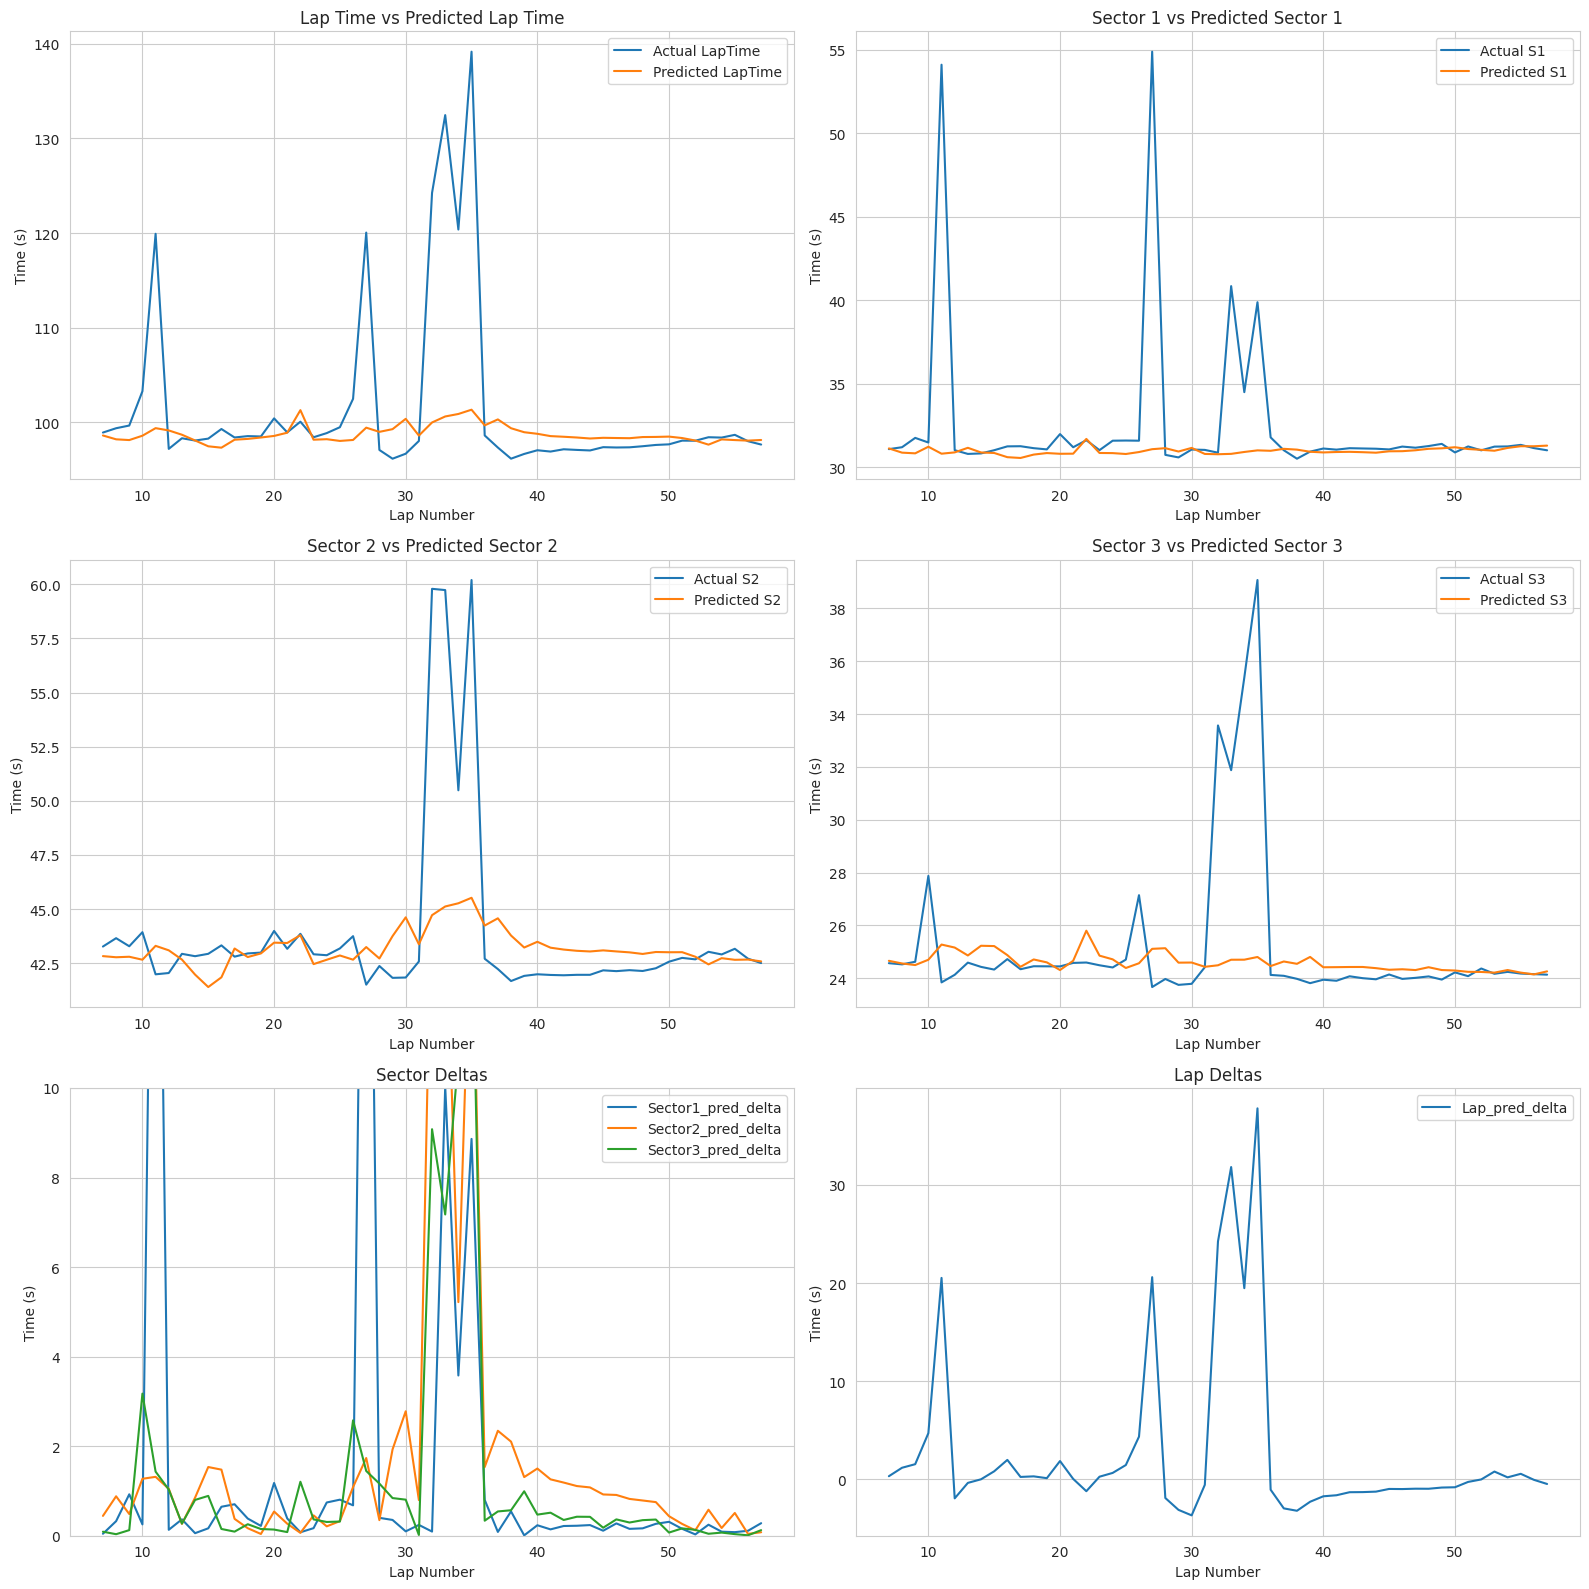

In [485]:


plt.figure(figsize=(16, 16))

# ----------------------------
# 1. LapTime vs Predicted LapTime
# ----------------------------
plt.subplot(3, 2, 1)
sns.lineplot(data=Test_pred_real, x="LapNumber", y="LapTime", label="Actual LapTime")
sns.lineplot(data=Test_pred_real, x="LapNumber", y="Predicted_LapTime", label="Predicted LapTime")
plt.title("Lap Time vs Predicted Lap Time")
plt.xlabel("Lap Number")
plt.ylabel("Time (s)")
# plt.ylim(90, 110)

# ----------------------------
# 2. Sector 1
# ----------------------------
plt.subplot(3, 2, 2)
sns.lineplot(data=Test_pred_real, x="LapNumber", y="Sector1Time", label="Actual S1")
sns.lineplot(data=Test_pred_real, x="LapNumber", y="Sector1_pred", label="Predicted S1")
plt.title("Sector 1 vs Predicted Sector 1")
plt.xlabel("Lap Number")
plt.ylabel("Time (s)")
# plt.ylim(25, 40)

# ----------------------------
# 3. Sector 2
# ----------------------------
plt.subplot(3, 2, 3)
sns.lineplot(data=Test_pred_real, x="LapNumber", y="Sector2Time", label="Actual S2")
sns.lineplot(data=Test_pred_real, x="LapNumber", y="Sector2_pred", label="Predicted S2")
plt.title("Sector 2 vs Predicted Sector 2")
plt.xlabel("Lap Number")
plt.ylabel("Time (s)")
# plt.ylim(25, 40)

# ----------------------------
# 4. Sector 3
# ----------------------------
plt.subplot(3, 2, 4)
sns.lineplot(data=Test_pred_real, x="LapNumber", y="Sector3Time", label="Actual S3")
sns.lineplot(data=Test_pred_real, x="LapNumber", y="Sector3_pred", label="Predicted S3")
plt.title("Sector 3 vs Predicted Sector 3")
plt.xlabel("Lap Number")
plt.ylabel("Time (s)")
# plt.ylim(25, 40)
# ----------------------------
# 5. Sector prediction deltas
# ----------------------------

plt.subplot(3, 2, 5)
sns.lineplot(data=Test_pred_real, x="LapNumber", y="Sector1_pred_delta", label="Sector1_pred_delta")
sns.lineplot(data=Test_pred_real, x="LapNumber", y="Sector2_pred_delta", label="Sector2_pred_delta")
sns.lineplot(data=Test_pred_real, x="LapNumber", y="Sector3_pred_delta", label="Sector3_pred_delta")
plt.title("Sector Deltas")
plt.xlabel("Lap Number")
plt.ylabel("Time (s)")
plt.ylim(0, 10)

# ----------------------------
# 6. Lap prediction deltas
# ----------------------------

plt.subplot(3, 2, 6)
sns.lineplot(data=Test_pred_real, x="LapNumber", y="Lap_pred_delta", label="Lap_pred_delta")
plt.title("Lap Deltas")
plt.xlabel("Lap Number")
plt.ylabel("Time (s)")
# plt.ylim(0, 20)

plt.tight_layout()
plt.show()